<a href="https://colab.research.google.com/github/mhmdsirajkhan/Customer_Segmentation_KMeans/blob/main/Cars_price_prediction_with_machine_Learning_pyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Found file: car data.csv

First 5 rows:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Data after converting text to numbers:
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0     ritz  2014           3.35           5.59       27000          0   
1      sx4  2013           4.75           9.54       43000          1   
2     ciaz  2017           7.25           9.

/tmp/ipython-input-2799806105.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)
/tmp/ipython-input-2799806105.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Selling_type':{'Dealer':0,'Individual':1}}, inplace=True)
/tmp/ipython-input-2799806105.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt

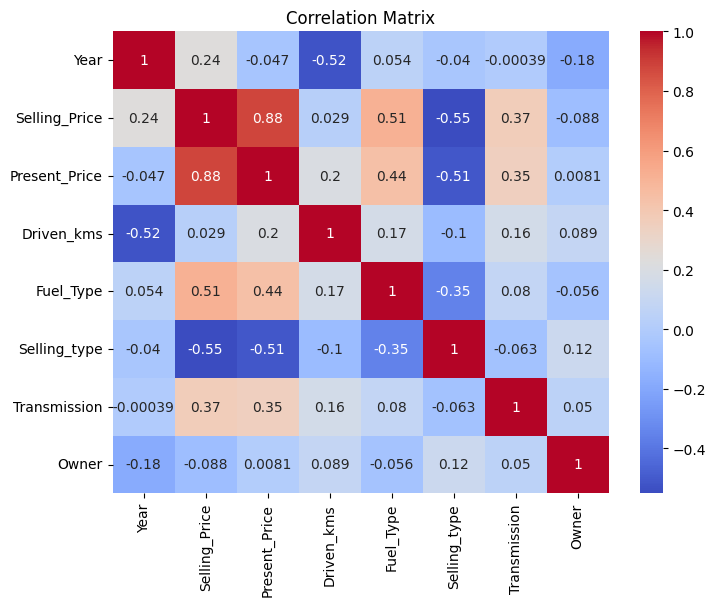

------------------------------
🎉 Model Performance (R2 Score): 0.96
------------------------------


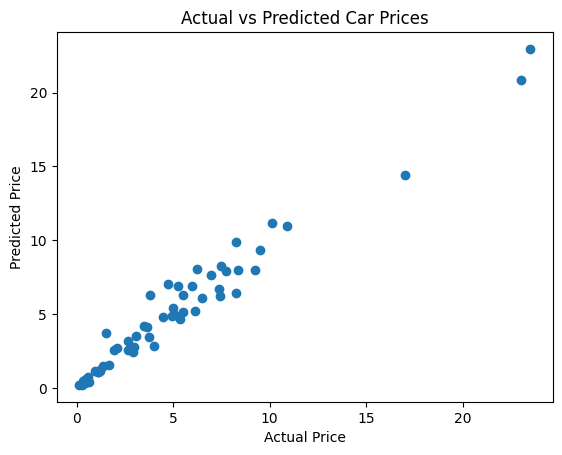

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import os

# --- STEP 1: LOAD THE FILE ---
csv_files = [f for f in os.listdir() if 'car' in f.lower() and f.endswith('.csv')]

if len(csv_files) == 0:
    print("❌ Error: No file found. Please upload 'car data.csv'.")
else:
    filename = csv_files[0]
    print(f"✅ Found file: {filename}")
    df = pd.read_csv(filename)

    # --- STEP 2: PREVIEW DATA ---
    print("\nFirst 5 rows:")
    print(df.head())

    # --- STEP 3: DATA PREPROCESSING ---
    # Convert text to numbers
    # (Note: Warnings about 'replace' are normal, you can ignore them)
    df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}}, inplace=True)
    df.replace({'Selling_type':{'Dealer':0,'Individual':1}}, inplace=True)
    df.replace({'Transmission':{'Manual':0,'Automatic':1}}, inplace=True)

    print("\nData after converting text to numbers:")
    print(df.head())

    # --- STEP 4: VISUALIZE CORRELATIONS ---
    # FIX: We add numeric_only=True to avoid the 'Car_Name' error
    plt.figure(figsize=(8,6))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

    # --- STEP 5: TRAIN THE MODEL ---
    # We drop 'Car_Name' because the name itself (as text) isn't used for math here
    X = df.drop(['Car_Name','Selling_Price'], axis=1)
    y = df['Selling_Price']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # --- STEP 6: EVALUATE ---
    predictions = model.predict(X_test)
    error_score = r2_score(y_test, predictions)

    print("-" * 30)
    print(f"🎉 Model Performance (R2 Score): {error_score:.2f}")
    print("-" * 30)

    # Plot results
    plt.scatter(y_test, predictions)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title('Actual vs Predicted Car Prices')
    plt.show()

In [5]:
# Define the new car data with column names so the model stays happy
new_car_data = pd.DataFrame([[2015, 9.85, 6900, 0, 0, 0, 0]],
                            columns=['Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'])

# Ask the model to predict
predicted_price = model.predict(new_car_data)

print(f"The AI suggests selling this car for: {predicted_price[0]:.2f} Lakhs")

The AI suggests selling this car for: 7.23 Lakhs
